# Bag of Words & Logistic Regression Classifier Baseline

In [8]:
import csv
import random

import pandas as pd

import matplotlib.pyplot as plt

from sklearn.linear_model import LogisticRegression
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.metrics import accuracy_score, f1_score, classification_report

In [2]:
languages = ['af', 'de', 'en', 'es', 'fr', 'id', 'it', 'nl', 'pt', 'sv', 'tl', 'tr']

In [23]:
# Load the train, test, validation data
train_dataset = []
test_dataset = []
validation_dataset = []

train_path = f"dataset/train.csv"
with open(train_path, 'r', encoding='utf-8') as f:
    reader = csv.DictReader(f)
    for row in reader:
        train_dataset.append(row)

    random.shuffle(train_dataset)
    train_dataset = [{'id': item['id'], 'text': item['text'], 'lang': item['lang']} for item in train_dataset]
    
test_path = f"dataset/test.csv"
with open(test_path, 'r', encoding='utf-8') as f:
    reader = csv.DictReader(f)
    for row in reader:
        test_dataset.append(row)

    random.shuffle(test_dataset)
    test_dataset = [{'id': item['id'], 'text': item['text']} for item in test_dataset]

validation_path = f"dataset/validation.csv"
with open(validation_path, 'r', encoding='utf-8') as f:
    reader = csv.DictReader(f)
    for row in reader:
        validation_dataset.append(row)

    random.shuffle(validation_dataset)
    validation_dataset = [{'id': item['id'], 'text': item['text'], 'lang': item['lang']} for item in validation_dataset]

## Visualizing the data

In [24]:
# Visualize the training dataset
print("Sample training data:")
train_df = pd.DataFrame(train_dataset)
train_df.head(10)

Sample training data:


,id,text,lang
0,4368,quero café,pt
1,4433,joue un peu de la musique du genre metal,fr
2,16964,scrivi una email a un familiare e rileggimela,it
3,13827,deniz kabuğunu tarif et,tr
4,903,spela ny musik från eldkvarn för mig,sv
5,6676,pulusi udara,id
6,3010,olly kuning muli ang liwanag para sa akin,tl
7,1762,anong oras na sa pilipinas ngayon,tl
8,850,une blague s'il vous plait,fr
9,11991,zeige mir welche läden um mich herum sind,de


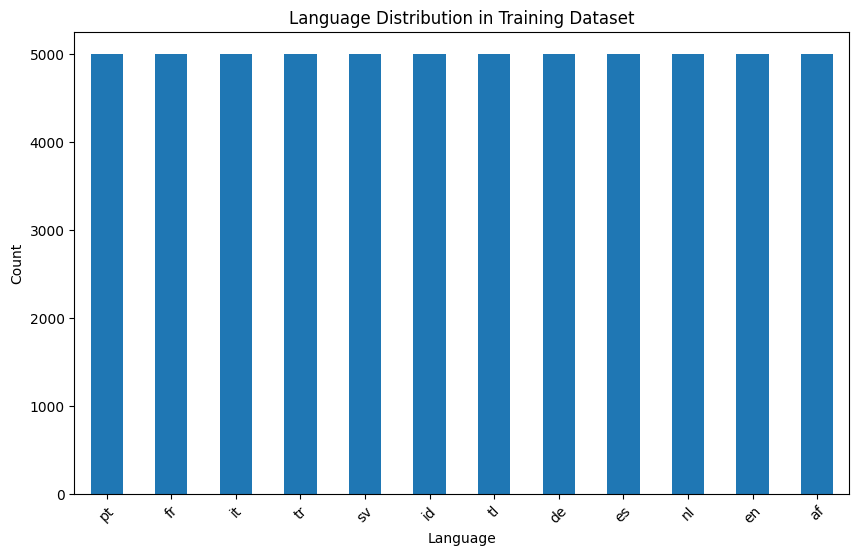

In [25]:
plt.figure(figsize=(10, 6))
train_df['lang'].value_counts().plot(kind='bar')
plt.title('Language Distribution in Training Dataset')
plt.xlabel('Language')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()

In [26]:
# Visualize the test dataset
print("Sample test data:")
test_df = pd.DataFrame(test_dataset)
test_df.head(10)

Sample test data:


,id,text
0,9352,allumer la radio
1,6290,wat sou jy vir my aanbeveel om te lees
2,10853,haal daardie daar af
3,10804,lê a minha lista de mercearias
4,10366,need for speed alta velocidade
5,6025,aurai-je besoin de la crème solaire cet après-...
6,9674,puedes poner mi audiolibro favorito de el traidor
7,7194,j'ai un réunion demain réglez-le
8,7889,a que horas é o jogo de futebol hoje à noite
9,334,ich möchte gern wissen wie das wetter in münch...


In [27]:
# Visualize the validation dataset
print("Sample validation data:")
validation_df = pd.DataFrame(validation_dataset)
validation_df.head(10)

Sample validation data:


,id,text,lang
0,582,wird es morgen regnen,de
1,741,toque músicas do género r. e b. e soul,pt
2,10450,vad finns på min shoppinglista idag,sv
3,13756,bana bilgi ver,tr
4,5636,heb ik dit weekend zonnebrandcrème nodig,nl
5,5216,geef mij het meest recente nieuws,nl
6,15207,ma mise à jour facebook toutes les trois heure...,fr
7,16478,verificar emails de carla,pt
8,16083,toon de laatste emails ollie,nl
9,9171,olly buat masukan kalender untuk sabtu depan p...,id


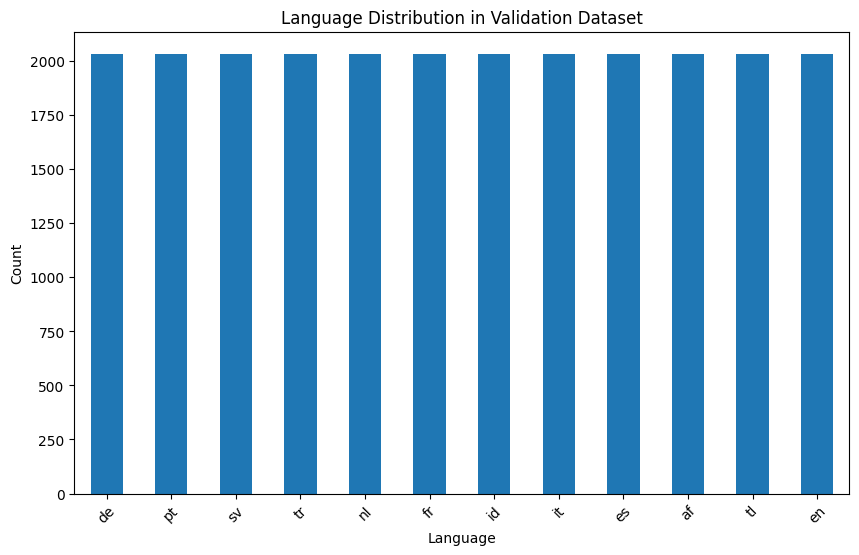

In [28]:
plt.figure(figsize=(10, 6))
validation_df['lang'].value_counts().plot(kind='bar')
plt.title('Language Distribution in Validation Dataset')
plt.xlabel('Language')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()

## Model Training

In [30]:
# Split the data into features and labels
X_train = [item['text'] for item in train_dataset]
y_train = [item['lang'] for item in train_dataset]

X_test = [item['text'] for item in test_dataset]

X_val = [item['text'] for item in validation_dataset]
y_val = [item['lang'] for item in validation_dataset]

In [34]:
# Create a BoW 
bow_vectorizer = CountVectorizer(lowercase=True, strip_accents=None)

X_train_bow = bow_vectorizer.fit_transform(X_train)
X_test_bow = bow_vectorizer.transform(X_test)
X_val_bow = bow_vectorizer.transform(X_val)

In [35]:
classifier = LogisticRegression()
classifier.fit(X_train_bow, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


## Model Evaluation

In [38]:
y_pred = classifier.predict(X_val_bow)

accuracy = accuracy_score(y_val, y_pred)
f1 = f1_score(y_val, y_pred, average='macro')

print(f"Accuracy: {accuracy*100:.4f}%")
print(f"F1 Score: {f1:.4f}")
print("\nClassification Report:")
print(classification_report(y_val, y_pred))

Accuracy: 97.0692%
F1 Score: 0.9711

Classification Report:
              precision    recall  f1-score   support

          af       0.97      0.95      0.96      2033
          de       0.99      0.97      0.98      2033
          en       0.98      0.97      0.98      2033
          es       0.98      0.95      0.97      2033
          fr       0.99      0.97      0.98      2033
          id       0.98      0.99      0.99      2033
          it       0.99      0.97      0.98      2033
          nl       0.97      0.95      0.96      2033
          pt       0.96      0.98      0.97      2033
          sv       0.99      0.97      0.98      2033
          tl       1.00      0.98      0.99      2033
          tr       0.85      0.99      0.92      2033

    accuracy                           0.97     24396
   macro avg       0.97      0.97      0.97     24396
weighted avg       0.97      0.97      0.97     24396



In [39]:
# Run your prediction on the test set and save the results to a CSV file
y_test_pred = classifier.predict(X_test_bow)

output_df = pd.DataFrame({'id': [item['id'] for item in test_dataset], 'lang': y_test_pred})
output_df.to_csv('prediction_results.csv', index=False)